In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3
import re

# Connect to the database
conn = sqlite3.connect("./data/nutrition.db")
cur = conn.cursor()

In [2]:
def normalize_text(str):
    if pd.isna(str):
        return ""
    str = str.lower()
    str = re.sub(r'[^a-z0-9\s]', ' ', str)
    str = re.sub(r'\s+', ' ', str).strip()
    return str

conn.create_function('normalize_text', 1, normalize_text)

wf_nutrients_query = """
SELECT fn.nutrient_id, wp.zip_code, wp.price, normalize_text(f.brand_owner)
FROM wholefoods_price wp
JOIN wf_match wm
    ON normalize_text(wp.product_name) = wm.wf_name
JOIN food_nutrient fn
    ON wm.fdc_id = fn.fdc_id
JOIN food f
    ON wm.fdc_id = f.fdc_id;
"""

wal_nutrients_query = """
SELECT fn.nutrient_id, wp.shipping_location, wp.price_retail, normalize_text(f.brand_owner)
FROM walmart_price wp
JOIN wf_match wm
    ON normalize_text(wp.product_name) = wm.wf_name
JOIN food_nutrient fn
    ON wm.fdc_id = fn.fdc_id
JOIN food f
    ON wm.fdc_id = f.fdc_id;
"""

wf_nutrients = pd.read_sql_query(wf_nutrients_query, conn)
wal_nutrients = pd.read_sql_query(wal_nutrients_query, conn)

In [3]:
import pgeocode
global_nomi = pgeocode.Nominatim('us')
def get_lat_lon(zip_code: int) -> (float, float):
    query = global_nomi.query_postal_code([str(zip_code)])
    return (query.latitude.iloc[0], query.longitude.iloc[0])

In [4]:
wf_nutrients['lat_lon'] = wf_nutrients['zip_code'].apply(get_lat_lon)
wf_nutrients[['latitude', 'longitude']] = pd.DataFrame(wf_nutrients['lat_lon'].tolist(), index=wf_nutrients.index)
wf_nutrients.drop(columns=['lat_lon'])

wal_nutrients['lat_lon'] = wal_nutrients['shipping_location'].apply(get_lat_lon)
wal_nutrients[['latitude', 'longitude']] = pd.DataFrame(wal_nutrients['lat_lon'].tolist(), index=wal_nutrients.index)
wal_nutrients = wal_nutrients.drop(columns=['lat_lon'])

wal_nutrients = wal_nutrients.rename(columns={'normalize_text(f.brand_owner)': 'brand_owner', 'price_retail': 'price', 'shipping_location': 'zip_code'})
wf_nutrients = wf_nutrients.rename(columns={'normalize_text(f.brand_owner)': 'brand_owner'})

In [5]:
from sklearn.preprocessing import LabelEncoder
wf_nutrients['source_wf'] = 1
wf_nutrients['source_wal'] = 0

wal_nutrients['source_wf'] = 0
wal_nutrients['source_wal'] = 1

shared_cols = ['nutrient_id', 'price', 'latitude', 'longitude', 'brand_owner', 'source_wf', 'source_wal', 'zip_code']
wf_selected = wf_nutrients[shared_cols]
wal_selected = wal_nutrients[shared_cols]

encoded_nutrients = pd.concat([wf_selected, wal_selected], ignore_index=True)
encoded_nutrients['brand_owner_encoded'] = LabelEncoder().fit_transform(encoded_nutrients.brand_owner)
encoded_nutrients = encoded_nutrients.drop(columns=['brand_owner'])
encoded_nutrients = encoded_nutrients.dropna()

In [6]:
# CALCULATE RESIDUALS

from sklearn.ensemble import RandomForestRegressor
X = encoded_nutrients[['nutrient_id', 'brand_owner_encoded', 'source_wf', 'source_wal', 'latitude', 'longitude']]
y = encoded_nutrients['price']

encoded_nutrients.to_sql("encoded_nutrients", conn, if_exists='replace', index=False)

model = RandomForestRegressor()
model.fit(X, y)

preds = model.predict(X)
encoded_nutrients['residual'] = y - preds

In [7]:
# CLUSTER RESIDUALS FOR DEVIATIONS
from sklearn.cluster import KMeans

residuals = encoded_nutrients[['residual', 'latitude', 'longitude']].values

kmeans = KMeans(n_clusters=30, random_state=42)
encoded_nutrients['residual_cluster'] = kmeans.fit_predict(residuals)

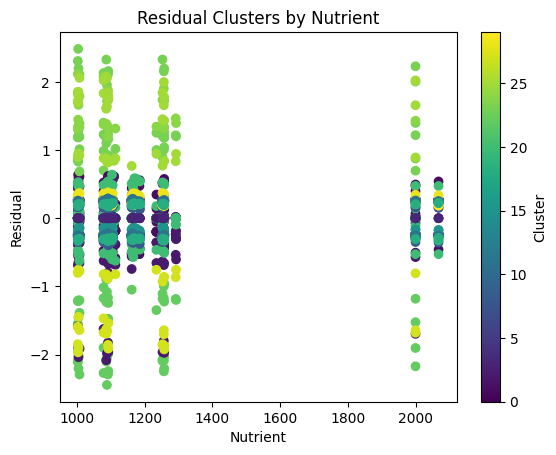

In [8]:
import matplotlib.pyplot as plt

# IMPENETRABLE HORROR MOVIE GRAPH
plt.scatter(encoded_nutrients.nutrient_id, encoded_nutrients['residual'], c=encoded_nutrients['residual_cluster'], cmap='viridis')
plt.xlabel('Nutrient')
plt.ylabel('Residual')
plt.title('Residual Clusters by Nutrient')
plt.colorbar(label='Cluster')
plt.show()

In [9]:
conn.close()